In [4]:
!pip install statsmodels prophet

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ----------------------------------- ---- 8.4/9.5 MB 43.4 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 31.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------- ----- 10.5/12.1 MB 48.5 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 37.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 21.9 MB/s eta 0:00:00

   ----- ---------------------------------- 1/7 [patsy]
   ----- ---------------------------------- 1/7 [patsy]
   ----- ---------------------------------- 1/7 [patsy]
   ----- ---------------------------------- 1/7 [patsy]
   ----- ---------------------------------- 1/7 [patsy]
   ----------- ---------------------------- 2/7 [importlib_resources]
   ----------- ---------------------------- 2/7 [imp

In [6]:
pip install plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------  9.7/9.9 MB 50.0 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 37.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
# loading packages
# basic + dates

import numpy as np
import pandas as pd

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# statistics 
from statsmodels.distributions.empirical_distribution import ECDF

# time series analysis
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# prophet by Facebook
from prophet import Prophet

In [3]:
# import 
import zipfile
import pandas as pd

zip_path = r"C:\Users\jhjgo\Desktop\conda_test\labs\practice_projects\Rossman\rossmann-store-sales.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    print("zip 내부 파일 목록:", z.namelist())

    with z.open('train.csv') as f:
        train = pd.read_csv(
            f,
            parse_dates= ['Date'],   # parse_dates= True: 날짜처럼 보이는 열을 가능한 경우 날짜형으로 변환하는 것
            low_memory= False,       # low_memory= False: 메모리를 아끼기 위해 데이터를 나눠서 추론하는 방식
            index_col= 'Date')     # index_col= 'Date' 열을 행 인덱스로 사용하겠다는 뜻

    with z.open('store.csv') as f:
        store = pd.read_csv(
            f,
            low_memory= False)

    with z.open('test.csv') as f:
        test = pd.read_csv(
            f,
            parse_dates= ['Date'],   # parse_dates= True: 날짜처럼 보이는 열을 가능한 경우 날짜형으로 변환하는 것
            low_memory= False,       # low_memory= False: 메모리를 아끼기 위해 데이터를 나눠서 추론하는 방식
            index_col= 'Date')

print("=====================")
print(train.head())
print(train.shape)
print(train.index)
print("=====================")
print(store.head())
print(train.shape)
print("=====================")
print(test.head())
print(test.shape)

zip 내부 파일 목록: ['sample_submission.csv', 'store.csv', 'test.csv', 'train.csv']
            Store  DayOfWeek  Sales  Customers  Open  Promo StateHoliday  \
Date                                                                       
2015-07-31      1          5   5263        555     1      1            0   
2015-07-31      2          5   6064        625     1      1            0   
2015-07-31      3          5   8314        821     1      1            0   
2015-07-31      4          5  13995       1498     1      1            0   
2015-07-31      5          5   4822        559     1      1            0   

            SchoolHoliday  
Date                       
2015-07-31              1  
2015-07-31              1  
2015-07-31              1  
2015-07-31              1  
2015-07-31              1  
(1017209, 8)
DatetimeIndex(['2015-07-31', '2015-07-31', '2015-07-31', '2015-07-31',
               '2015-07-31', '2015-07-31', '2015-07-31', '2015-07-31',
               '2015-07-31', '2015-07-

In [4]:
# @@@ EDA (Exploratory Data Analysis) @@@
# first glance at the train set: head and tail

print("In total: ", train.shape)
train.head()

In total:  (1017209, 8)


,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,
2015-07-31,1,5,5263,555,1,1,0,1
2015-07-31,2,5,6064,625,1,1,0,1
2015-07-31,3,5,8314,821,1,1,0,1
2015-07-31,4,5,13995,1498,1,1,0,1
2015-07-31,5,5,4822,559,1,1,0,1


In [5]:
# data extraction
train['Year'] = train.index.year
train['Month'] = train.index.month
train['Day'] = train.index.day
# train['WeekOfYear'] = train.index.weekofyear
train['WeekOfYear'] = train.index.isocalendar().week.astype(int)

# adding new variable
# Sale Per Customer = Sales, Customers 가 모두 given day 로 기간이 일치함으로 계산 가능
train['SalePerCustomer']= train['Sales']/train['Customers']
train['SalePerCustomer'].describe()

# 평균 9.5유로 판매
# 그러나, 0유로 판매액인 날도 존재함

count    844340.000000
mean          9.493619
std           2.197494
min           0.000000
25%           7.895563
50%           9.250000
75%          10.899729
max          64.957854
Name: SalePerCustomer, dtype: float64

Text(0.5, 0, 'Sale per Customer')

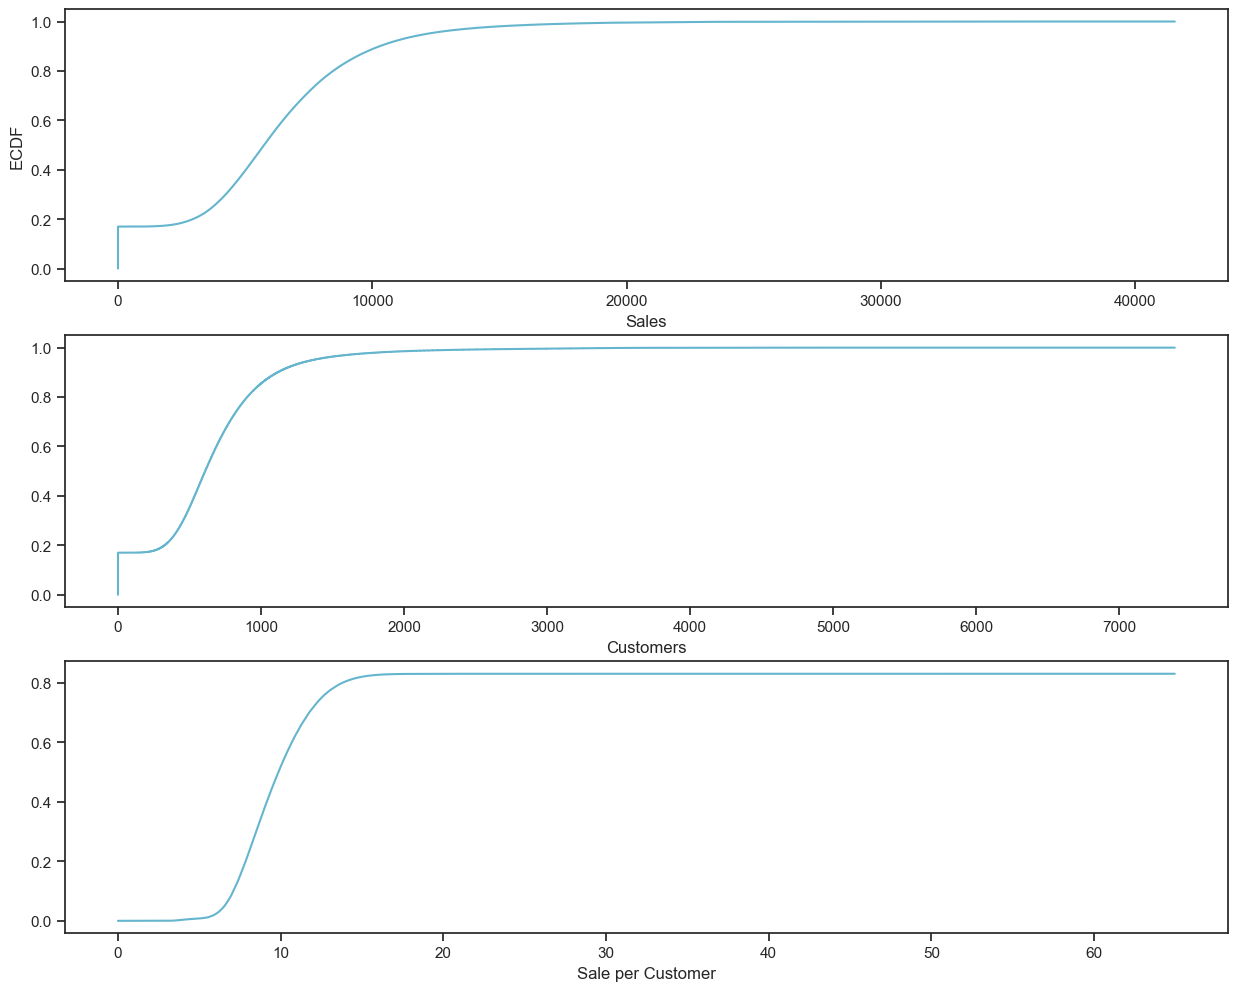

In [6]:
# ECDF: Empirical Cumulative Distriubution Function
# 경험적 누적 분포 함수 - 실제 관측된 데이터를 기반으로 작성한 누적 분포 함수
# 전체 표본 중 특정 값 x보다 작거나 같은 데이터의 비율을 계산하여, 모집단의 분포를 추정하는 계단 형태의 그래프

# to format into seaborn
sns.set(style= 'ticks')
plt.figure(figsize= (15, 12))

plt.subplot(311)     # subplot(311) -> 3행 1열 구조의 서브플롯의 1번째
cdf= ECDF(train['Sales'])  # ECDF(): statsmodels 에서 제공하는 함수
plt.plot(cdf.x, cdf.y, label= 'statmodels', color= 'c')   # cdf.x: 정렬된 x 값, cdf.y: snwjr ghkrfbf
plt.xlabel('Sales')
plt.ylabel('ECDF')

# plot second ECDF
plt.subplot(312)
cdf= ECDF(train['Customers'])
plt.plot(cdf.x, cdf.y, label= 'statmodels', color= 'c')
plt.xlabel('Customers')

# plot second ECDF
plt.subplot(313)
cdf= ECDF(train['SalePerCustomer'])
plt.plot(cdf.x, cdf.y, label= 'statmodels', color= 'c')
plt.xlabel('Sale per Customer')

# 20% 정도의 데이터가 0의 판매와 고객을 나타냄
# 80% 정도의 일일 판매량이 10000 미만임

In [16]:
### Missing values

# Closed stores and zero sales store

# closed stores

train[(train.Open == 0) & (train.Sales == 0)].head()


,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,Day,WeekOfYear,SalePerCustomer
Date,,,,,,,,,,,,,
2015-07-31,292,5,0,0,0,1,0,1,2015,7,31,31,NaN
2015-07-31,876,5,0,0,0,1,0,1,2015,7,31,31,NaN
2015-07-30,292,4,0,0,0,1,0,1,2015,7,30,31,NaN
2015-07-30,876,4,0,0,0,1,0,1,2015,7,30,31,NaN
2015-07-29,292,3,0,0,0,1,0,1,2015,7,29,31,NaN


In [ ]:
train[(train.Open == 0) & (train.Sales ==0)].shape

# 172,817 점포가 닫은 상태임 -> 관측치에서 약 10% 를 차지함

(172817, 13)

In [ ]:
# opened stores with zero sales

zero_sales = train[(train.Open == 1) & (train.Sales == 0)]
print("In total: ", zero_sales.shape)
print("="*30)
zero_sales.head()

# 54개의 점포가 운영을 하고 있음에도 판매가 0유로임
# -> 외부 요인이 작용하고 있을 수 있음

In total:  (54, 13)


,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,Day,WeekOfYear,SalePerCustomer
Date,,,,,,,,,,,,,
2015-05-15,971,5,0,0,1,0,0,1,2015,5,15,20,NaN
2015-03-26,674,4,0,0,1,0,0,0,2015,3,26,13,NaN
2015-02-05,699,4,0,0,1,1,0,0,2015,2,5,6,NaN
2014-10-01,708,3,0,0,1,1,0,0,2014,10,1,40,NaN
2014-09-22,357,1,0,0,1,0,0,0,2014,9,22,39,NaN


In [26]:
print("Closed stores and days which didn't have any sales won't be counted into the forecasts.")
train = train[(train['Open'] == 1) & (train['Sales'] != 0)]
print("In total: ", train.shape)

Closed stores and days which didn't have any sales won't be counted into the forecasts.
In total:  (844338, 13)


In [27]:
# additional information about the stores

store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [28]:
store.shape

(1115, 10)

In [ ]:
### missing value

store.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [ ]:
# missing value 1 - CompetitionDistance
# CompetitonDistance: distance in meters to the nearest competitor store

store[pd.isnull(store.CompetitionDistance)]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
290,291,d,a,NaN,NaN,NaN,0,NaN,NaN,NaN
621,622,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN
878,879,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"


In [32]:
# simply missing from the data
# No particular pattern obsereved

# Replace Nan with the median values

# fill NaN witha a medain value (skewed distribution)

store['CompetitionDistance'].fillna(store['CompetitionDistance'].median(), inplace= True)

C:\Users\jhjgo\AppData\Local\Temp\ipykernel_32520\1773780298.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  store['CompetitionDistance'].fillna(store['CompetitionDistance'].median(), inplace= True)


In [ ]:
# missing value 2 - Promo2SinceWeek
# Promo2SinceWeek: describes the time when the store started participating in Promo

_ = store[pd.isnull(store.Promo2SinceWeek)]
_[_.Promo2 != 0].shape  # Promo 0 = store is not participating

(0, 10)

In [ ]:
# replace NA's by 0

# Promo2 가 정보가 없으면 정보도 없는 것임 ->  따라서 0으로 치환해도 됨
# **544개씩 비어있는 이유가 Promo2가 0인 매장이라고 가정한 것임

store.fillna(0, inplace= True)

In [ ]:
print("Joining train set with an additional store information.")

#  by specifying inner join we make sure that only those observations
# that are present in both train and store sets are merged together
train_store= pd.merge(train, store, how = 'inner', on = 'Store')     # Store 열 기준으로 두가지 데이터를 합침
                                                                     # on= '': ''라는 공통 열을 기준으로 붙임
                                                                     # how= 'inner': 내부 조인 => train, store 둘 다 존재하는 Store만 남김

print("In total: ", train_store.shape)
train_store.head()

Joining train set with an additional store information.
In total:  (844338, 22)


,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,...,SalePerCustomer,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,5263,555,1,1,0,1,2015,7,...,9.482883,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
1,2,5,6064,625,1,1,0,1,2015,7,...,9.702400,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,8314,821,1,1,0,1,2015,7,...,10.126675,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,13995,1498,1,1,0,1,2015,7,...,9.342457,c,c,620.0,9.0,2009.0,0,0.0,0.0,0
4,5,5,4822,559,1,1,0,1,2015,7,...,8.626118,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0


In [ ]:
### Store types

# StoreType 에 따라 주 메트릭인 Sales가 어떻게 분포되어있는지 확인하기

train_store.groupby('StoreType')['Sales'].describe()

# StoreType B가 가장 높은 평균을 가짐, 매장 수가 가장 적음, 평균, 최소, 최대 등 모든 면에서 가장 높음

,count,mean,std,min,25%,50%,75%,max
StoreType,,,,,,,,
a,457042.0,6925.697986,3277.351589,46.0,4695.25,6285.0,8406.00,41551.0
b,15560.0,10233.380141,5155.729868,1252.0,6345.75,9130.0,13184.25,38722.0
c,112968.0,6933.126425,2896.958579,133.0,4916.00,6408.0,8349.25,31448.0
d,258768.0,6822.300064,2556.401455,538.0,5050.00,6395.0,8123.25,38037.0


In [ ]:
# See which StoreType is the most selling and crowded one
# -> Sales, Customers

train_store.groupby('StoreType')[['Customers', 'Sales']].sum()  # 여러 열을 고르려면 list 형식으로 작성해야함

# A가 가장 많은 고객과 판매액을 가짐, D - C - B 의 순서로 고객수와 매출액이 큼

,Customers,Sales
StoreType,,
a,363541431,3165334859
b,31465616,159231395
c,92129705,783221426
d,156904995,1765392943


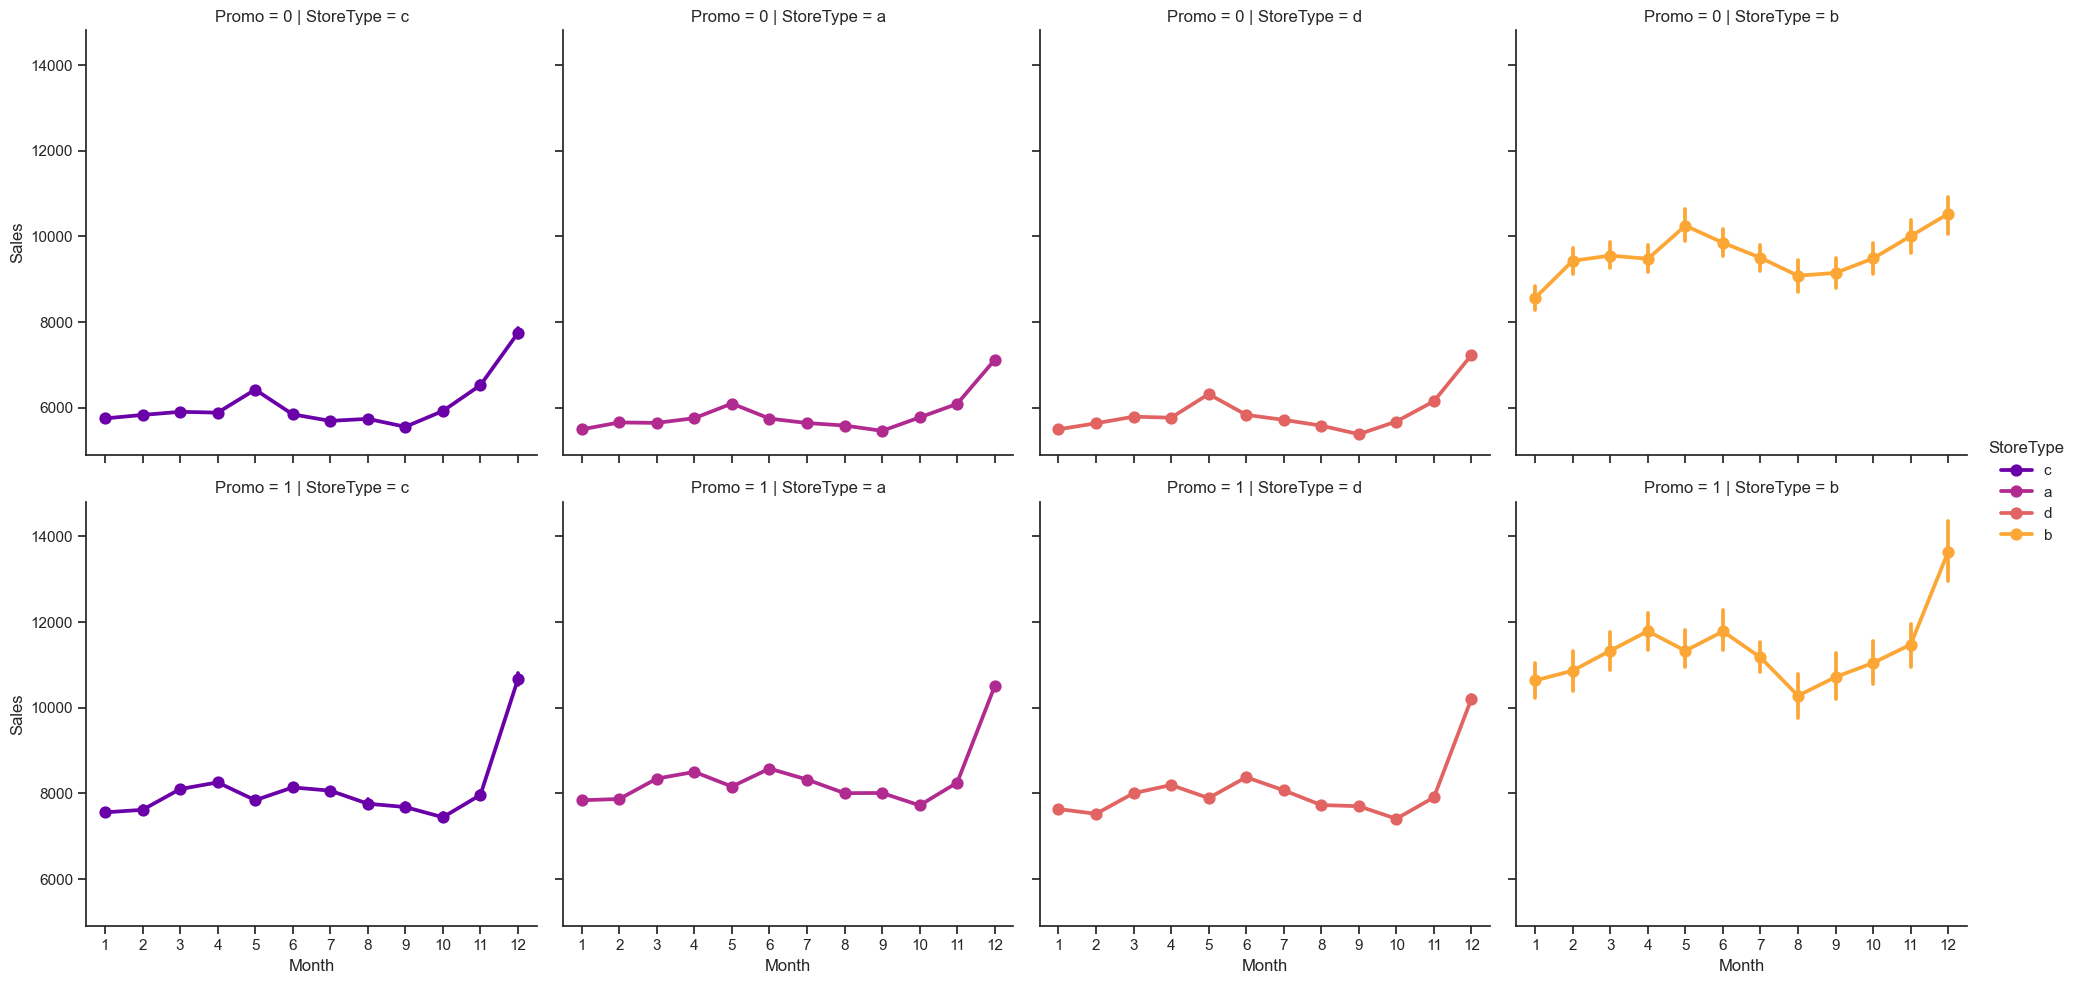

In [ ]:
# 기간 동안 판매 추이를 보기 위한 그래프 1 - StoreType

# catplot: 범주형 변수 중심 시각화 함수

sns.catplot(data= train_store,    # factorplot 은 catplot으로 대체됨
               x= 'Month', 
               y= 'Sales',
               col= 'StoreType',  # per store type in cols
               palette= 'plasma',
               hue= 'StoreType',
               row= 'Promo',   # per promo in the store in row
               color= 'c',
               kind= 'point'
               )

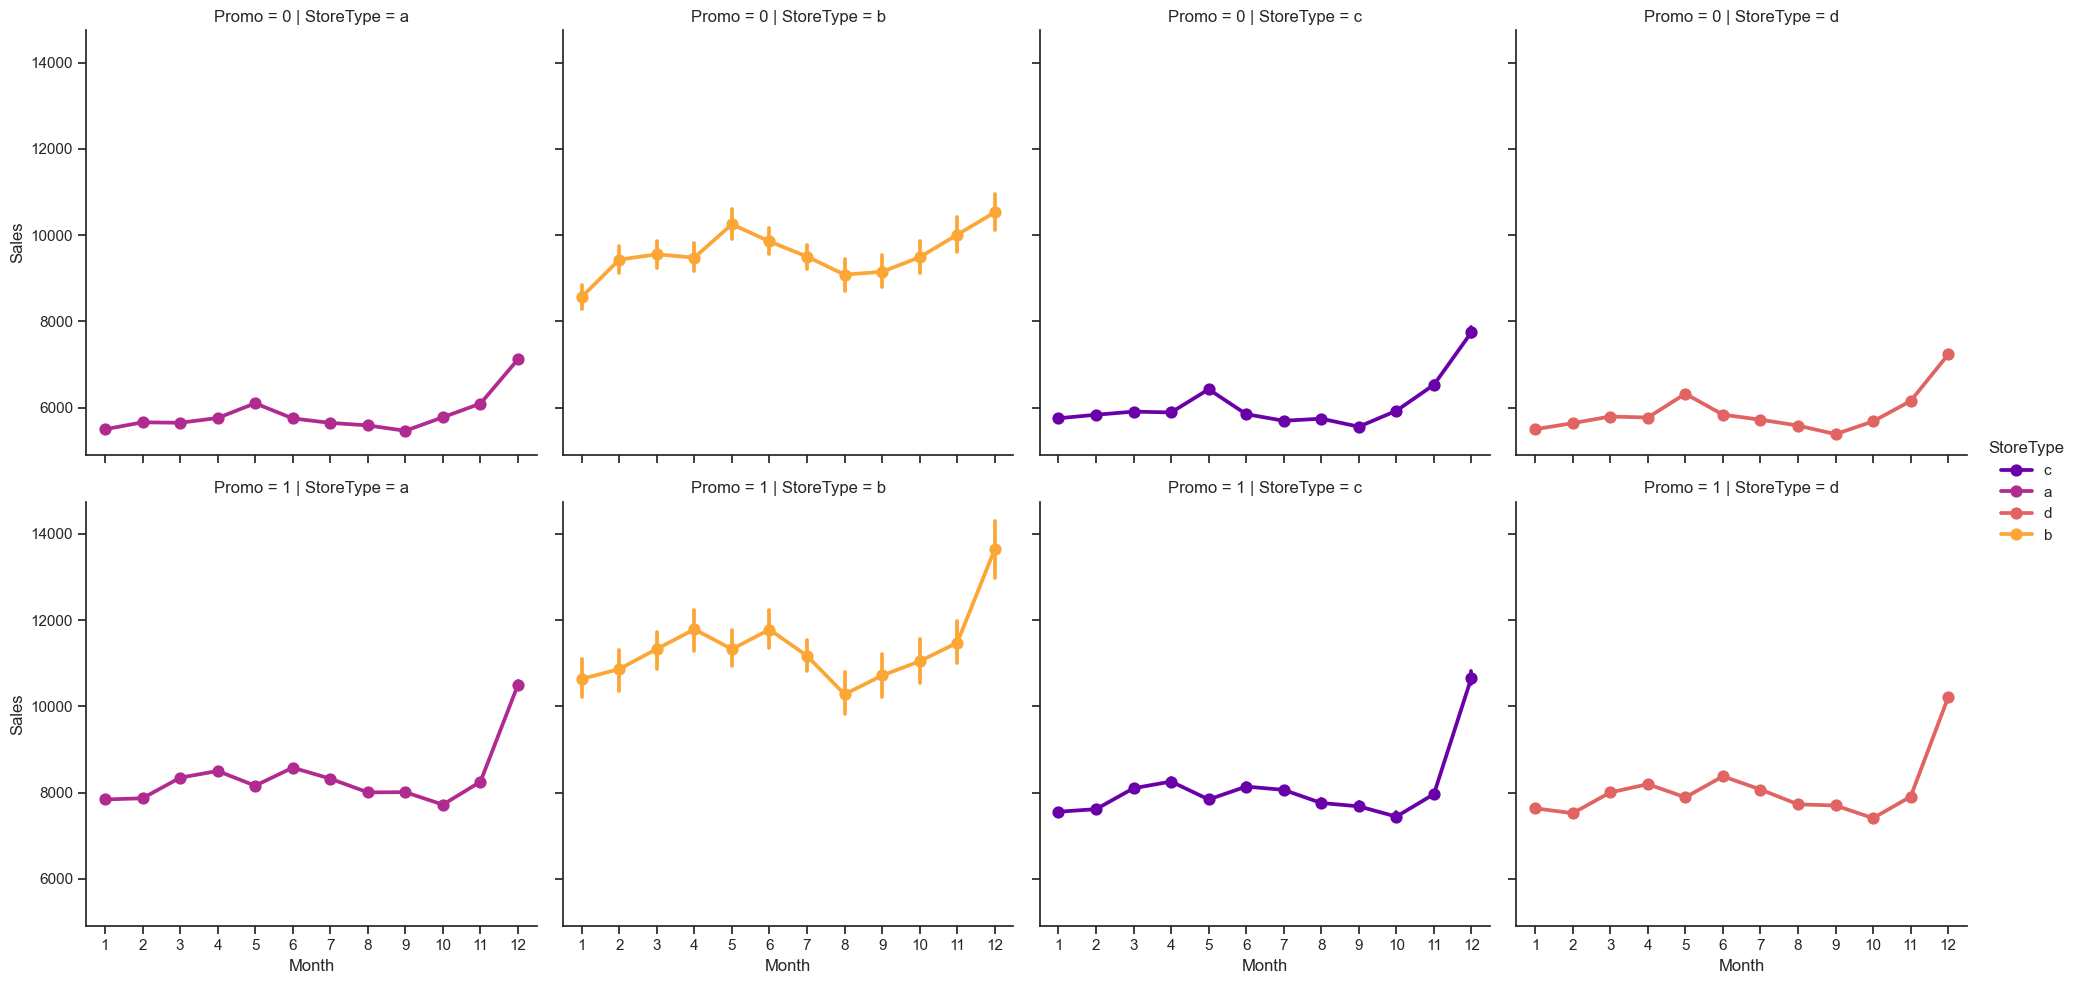

In [ ]:
# 기간 동안 가게 유형 별 판매 추이를 보기 위한 그래프 1 - Sales

# catplot: 범주형 변수 중심 시각화 함수

storetype_order = ['a', 'b', 'c', 'd']

sns.catplot(data= train_store,    # factorplot 은 catplot으로 대체됨
               x= 'Month', 
               y= 'Sales',
               col= 'StoreType',  # per store type in cols
               col_order= storetype_order,
               palette= 'plasma',
               hue= 'StoreType',
               row= 'Promo',   # per promo in the store in row
               color= 'c',
               kind= 'point'
               )

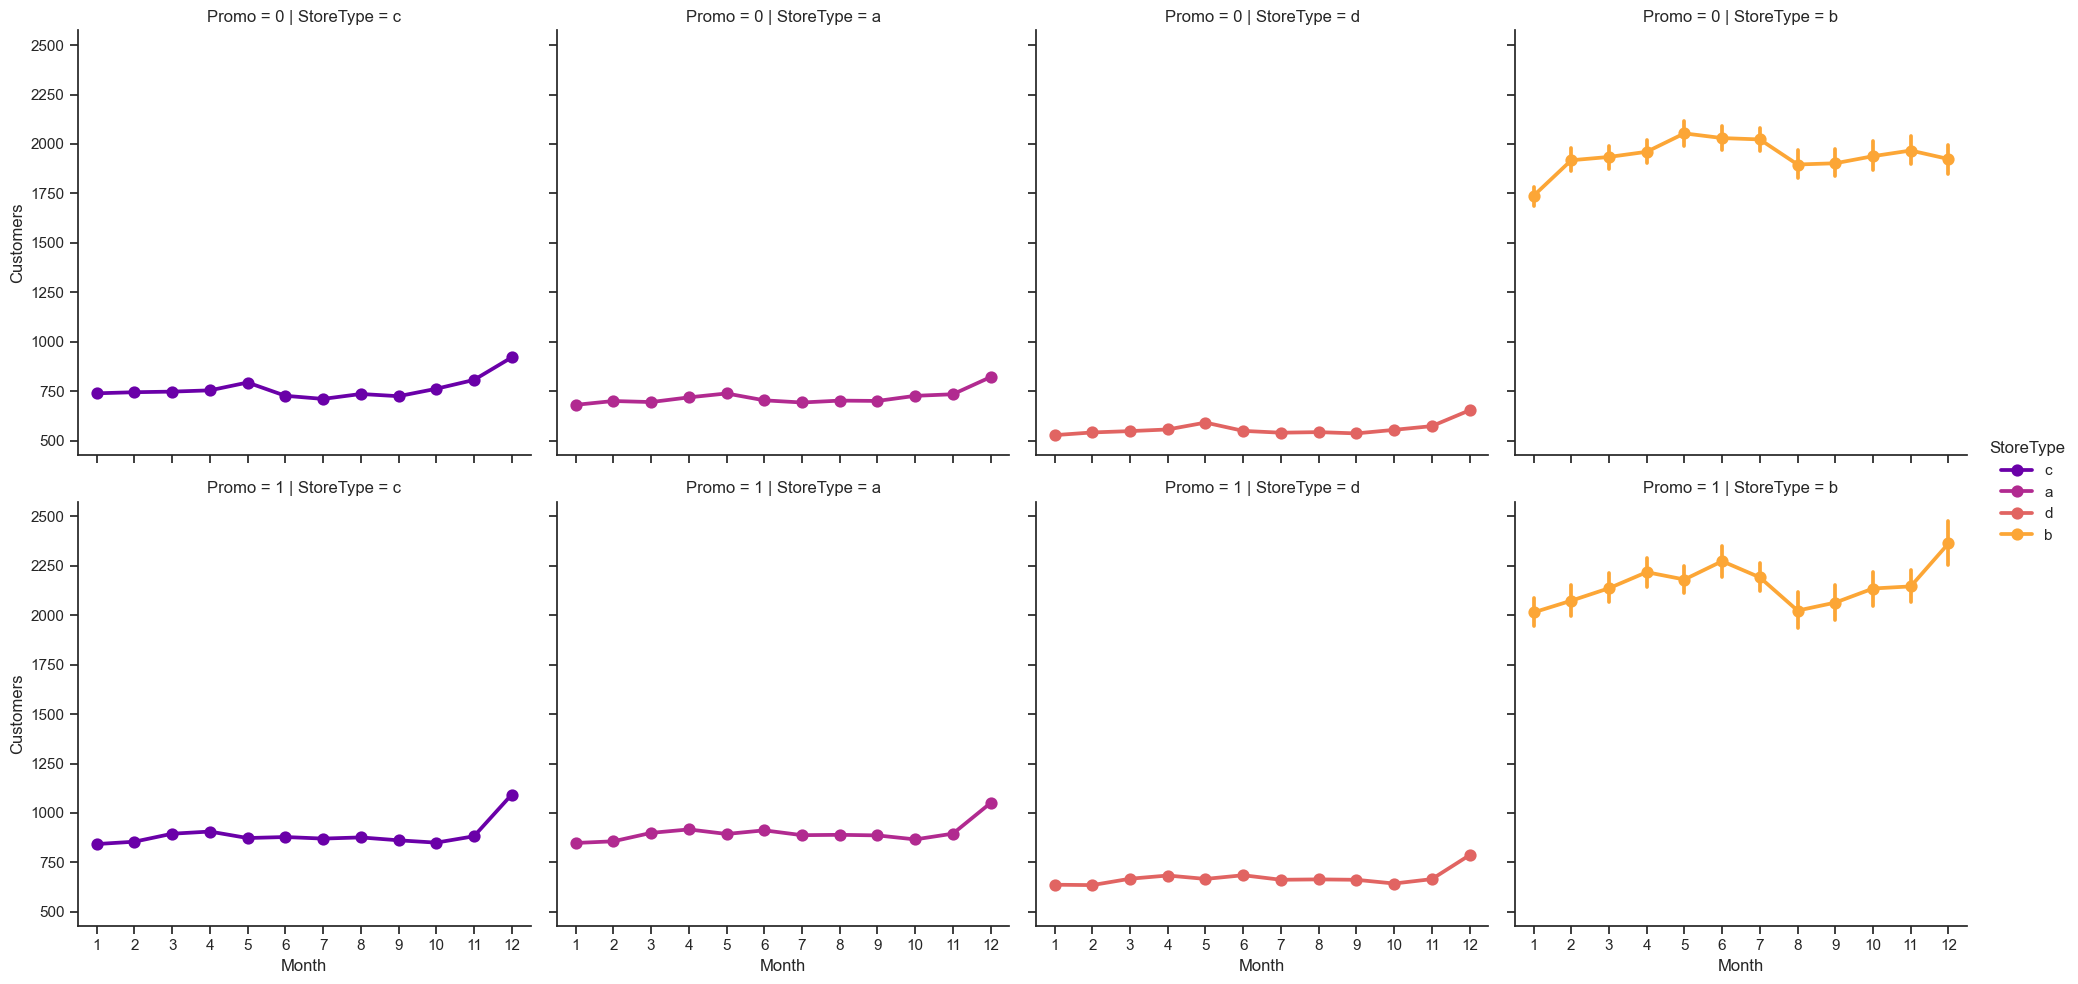

In [ ]:
# 기간 동안 가게 유형 별 판매 추이 그래프 2 - 고객수 별

sns.catplot(data= train_store,
            x= 'Month',
            y= 'Customers',
            col= 'StoreType',
            palette= 'plasma',
            hue= 'StoreType',
            row= 'Promo',
            color= 'c',
            kind= 'point')

# 모든 가게 유형은 똑같은 추세를 보임 그러나 프로모션의 유무나 가게 타입에 따라 규모가 달라지기는 함 (예: B)
# 12월 크리스마스 휴일에 판매량, 고객수가 올라가는 것을 알 수 있음

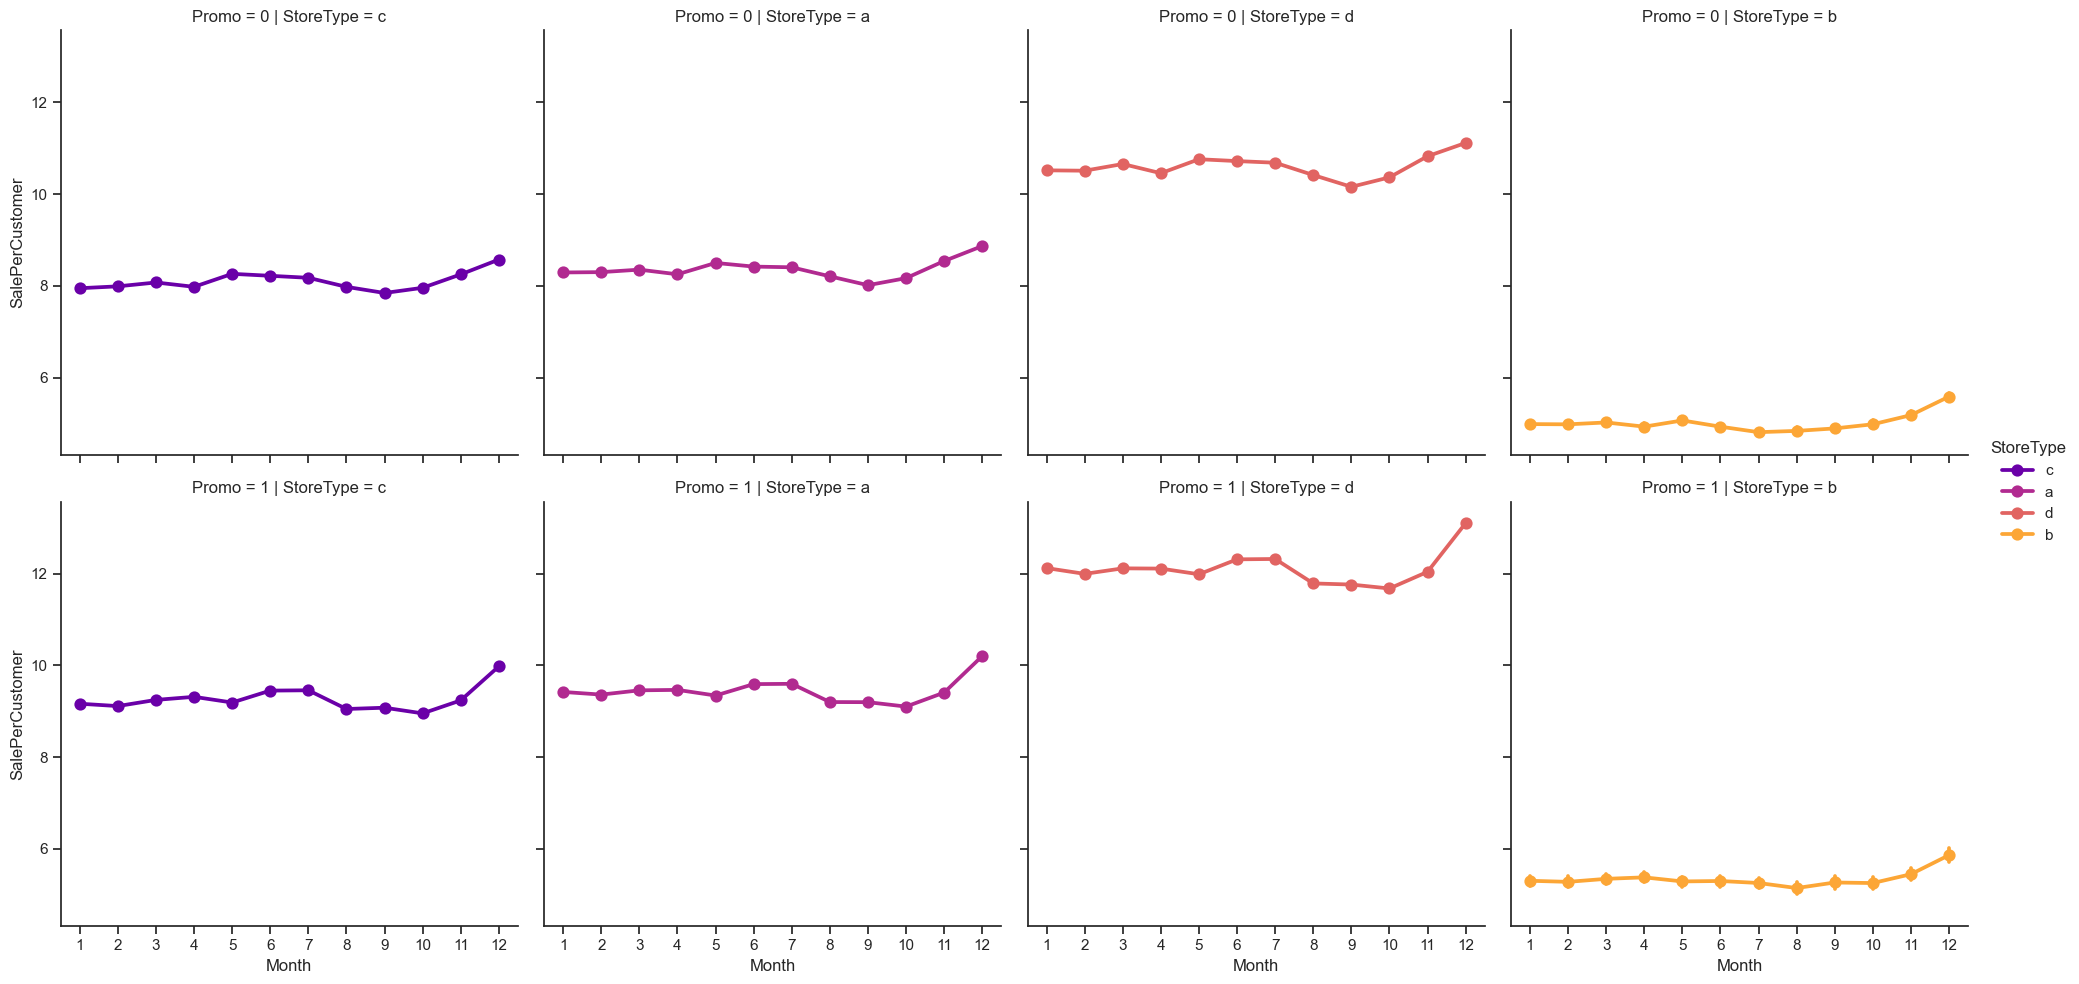

In [ ]:
# sale per customer trends

sns.catplot(data= train_store,
            x= 'Month',
            y= 'SalePerCustomer',
            col= 'StoreType',
            palette= 'plasma',
            hue= 'StoreType',
            row= 'Promo',
            color= 'c',
            kind= 'point')

# D 가 압도적으로 높고, B 가 생각했던 것 보다 낮다 => 매장 수가 적은 것에 비해 고객수가 많은 것 같기도 ?
# D: 평균적으로 프로모션이 없으면 10유로, 프로모션이 있으면 12유로의 판매액을 보인다
# B: Buyer Cart를 나타냄: 만흥 사람들이 작은 물건이나 적은 양의 물건만 삼

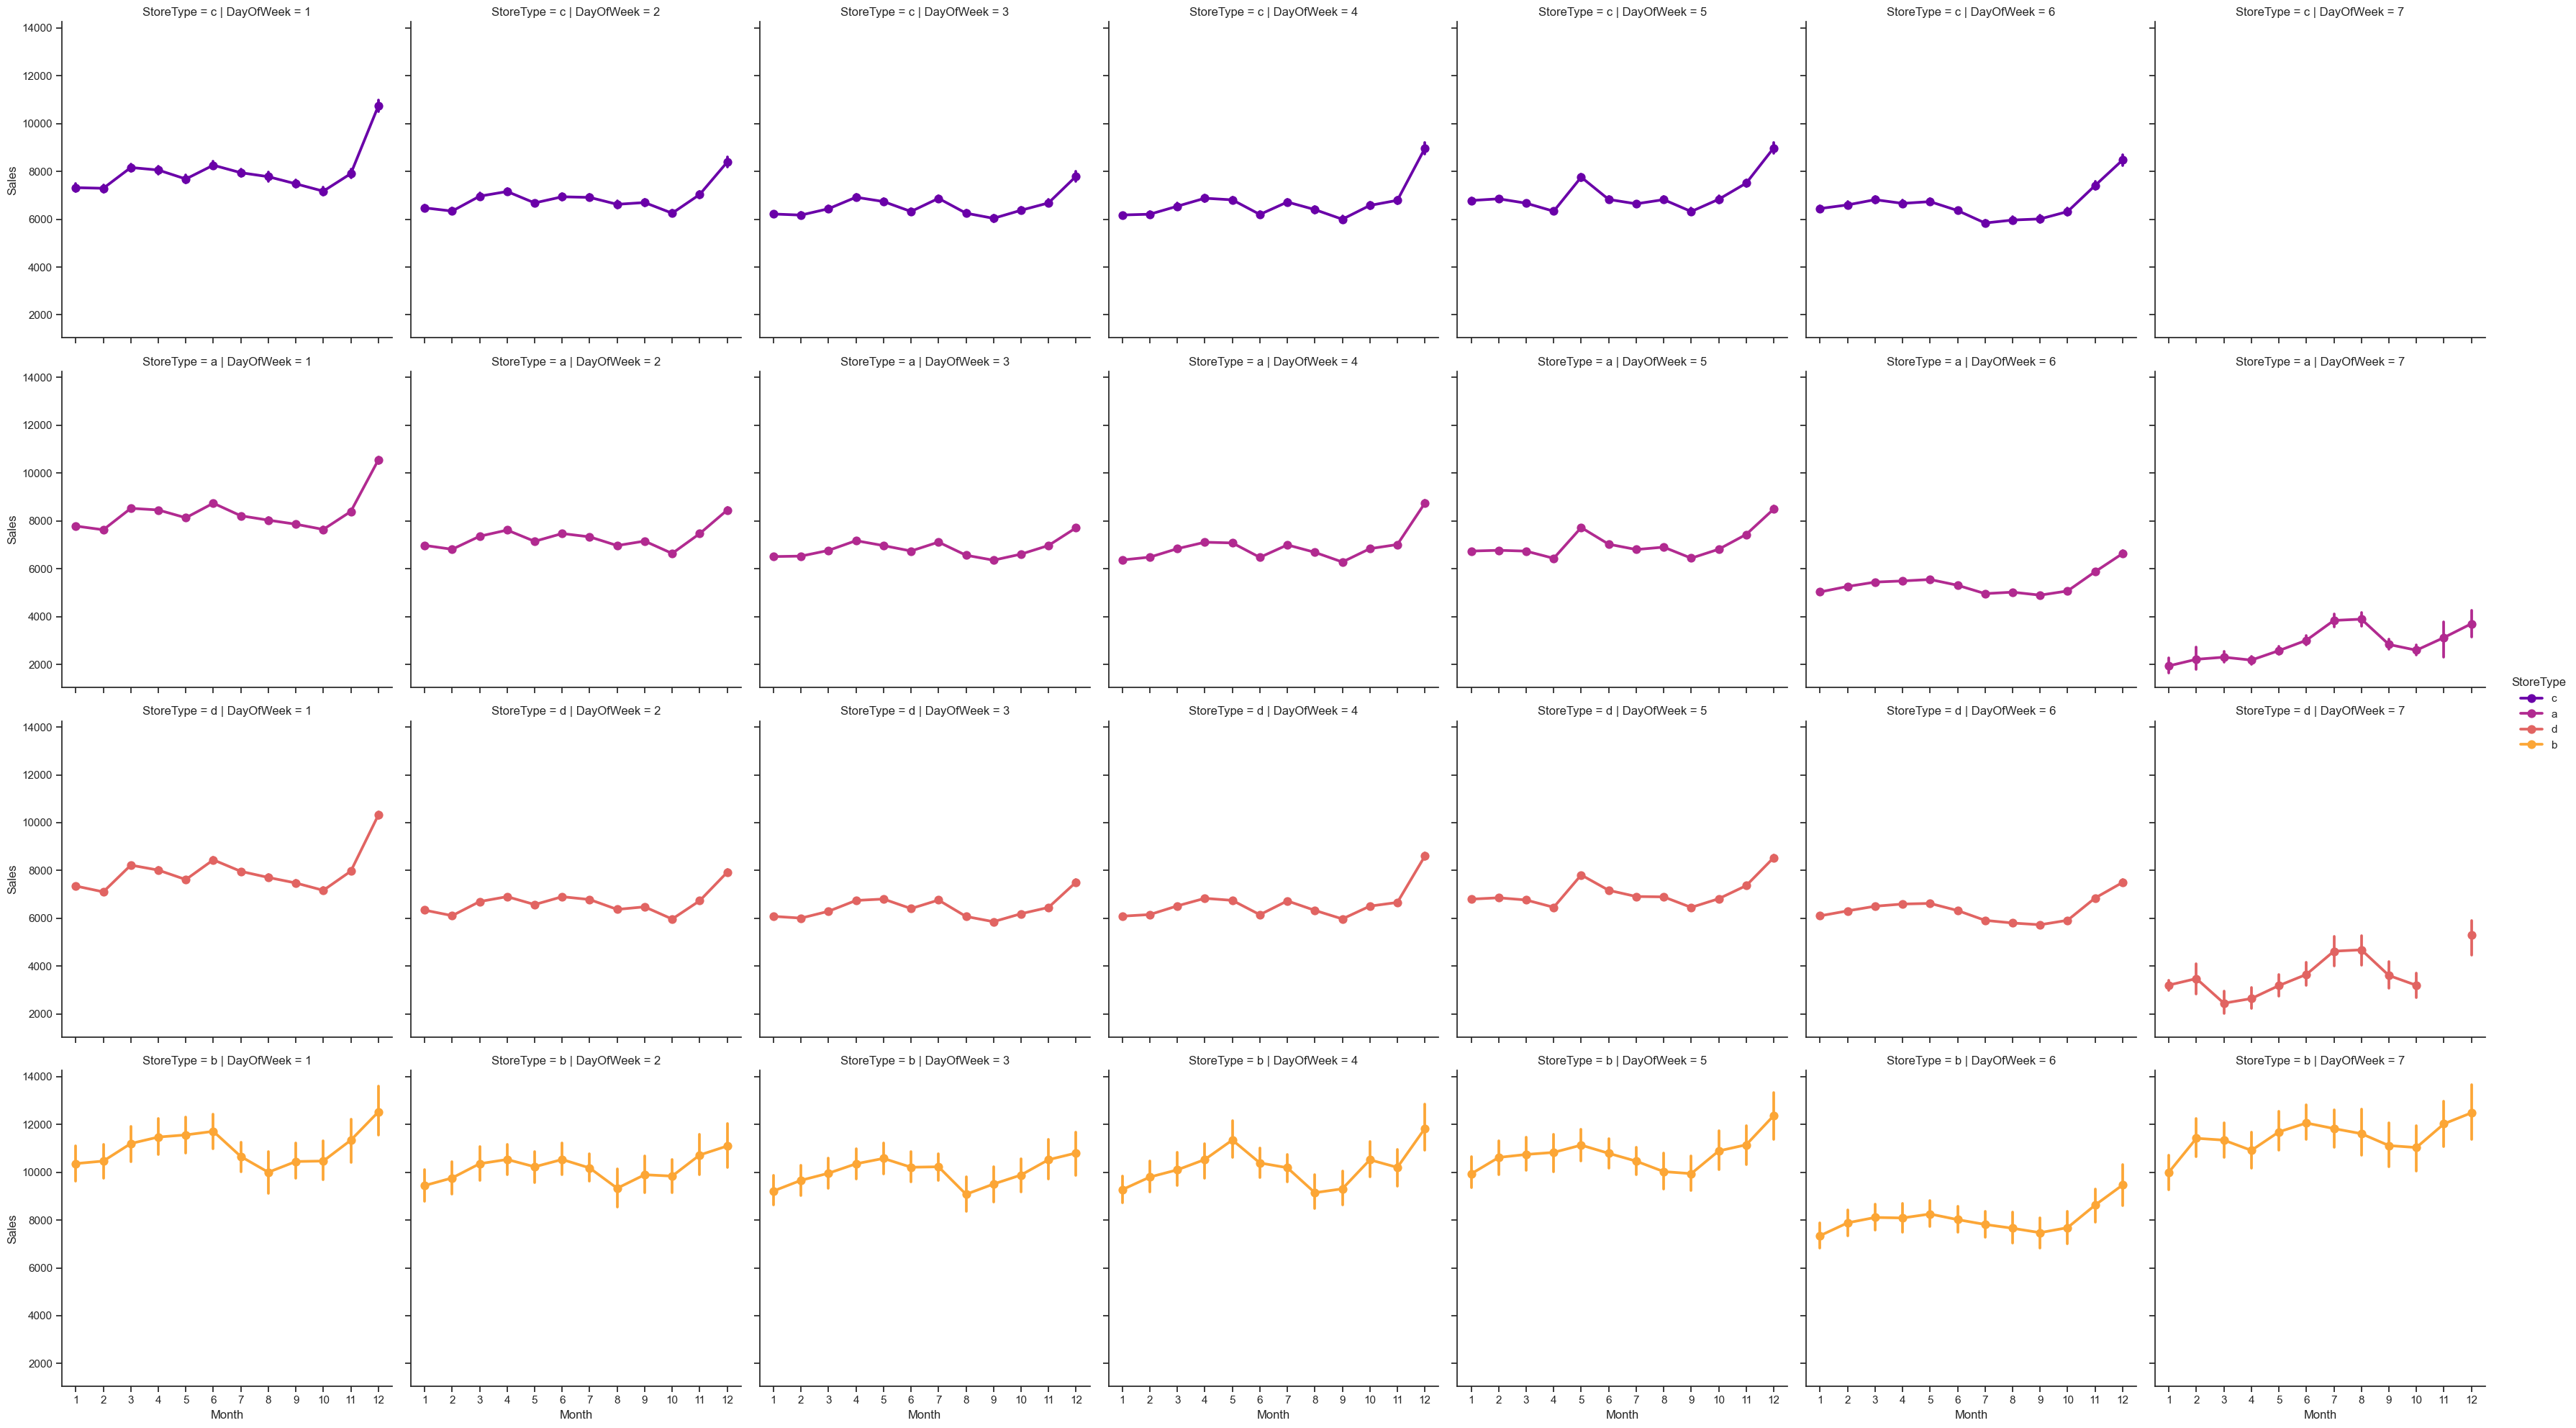

In [ ]:
# customers

# DayOfWeek: 월화수목금토일

sns.catplot(data= train_store,
            x= 'Month',
            y= 'Sales',
            col= 'DayOfWeek',  # per store type in cols
            palette= 'plasma',
            hue= 'StoreType',
            row= 'StoreType',  # per store type in rows
            color= 'c',
            kind= 'point')

# C 매장은 일요일에 열지 않는 매장
# D 매장은 11월에는 일요일에 열지 않았음
# 공통적으로 12월 월요일에 가장 방문 고객이 많음

In [66]:
# stores which are opened on Sundays

train_store[(train_store.Open == 1) & (train_store.DayOfWeek == 7)]['Store'].unique()

array([  85,  122,  209,  259,  262,  274,  299,  310,  335,  353,  423,
        433,  453,  494,  512,  524,  530,  562,  578,  676,  682,  732,
        733,  769,  863,  867,  931,  948, 1045, 1081, 1097, 1099,  877])

In [ ]:
# competition open time (in months)

train_store['CompetitionOpen'] = 12 * (train_store.Year - train_store.CompetitionOpenSinceYear) + \
                                (train_store.Month - train_store.CompetitionOpenSinceMonth) 

# Promo open time
train_store['PromoOpen'] = 12 * (train_store.Year - train_store.Promo2SinceYear) + \
                           (train_store.WeekOfYear - train_store.Promo2SinceWeek) / 4.0

# replace NA's by 0
train_store.fillna(0, inplace= True)

# average PromoOpen time and CompetitionOpen time per store type
train_store.loc[:, ['StoreType', 
                    'Sales',
                    'Customers',
                    'PromoOpen',
                    'CompetitionOpen']].groupby('StoreType').mean()

# B: 프로모션 기간이 길고 경쟁가게와 노출이 되는 기간이 가장 길다
# A: 가장 판매가 많고 손님이 많은 매장, 경장 가게와 노출되는 기간이 길지 않음 ??? 이거 해석을 잘 이해못하겟음

,Sales,Customers,PromoOpen,CompetitionOpen
StoreType,,,,
a,6925.697986,795.422370,12918.492198,7115.514452
b,10233.380141,2022.211825,17199.328069,11364.495244
c,6933.126425,815.538073,12158.636107,6745.418694
d,6822.300064,606.353935,10421.916846,9028.526526


In [ ]:
train_store = train_store.drop(columns= ['PormoOpen'])

In [81]:

print(train_store.columns)

Index(['Store', 'DayOfWeek', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'Year', 'Month', 'Day', 'WeekOfYear',
       'SalePerCustomer', 'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval',
       'CompetitionOpen', 'PromoOpen'],
      dtype='object')


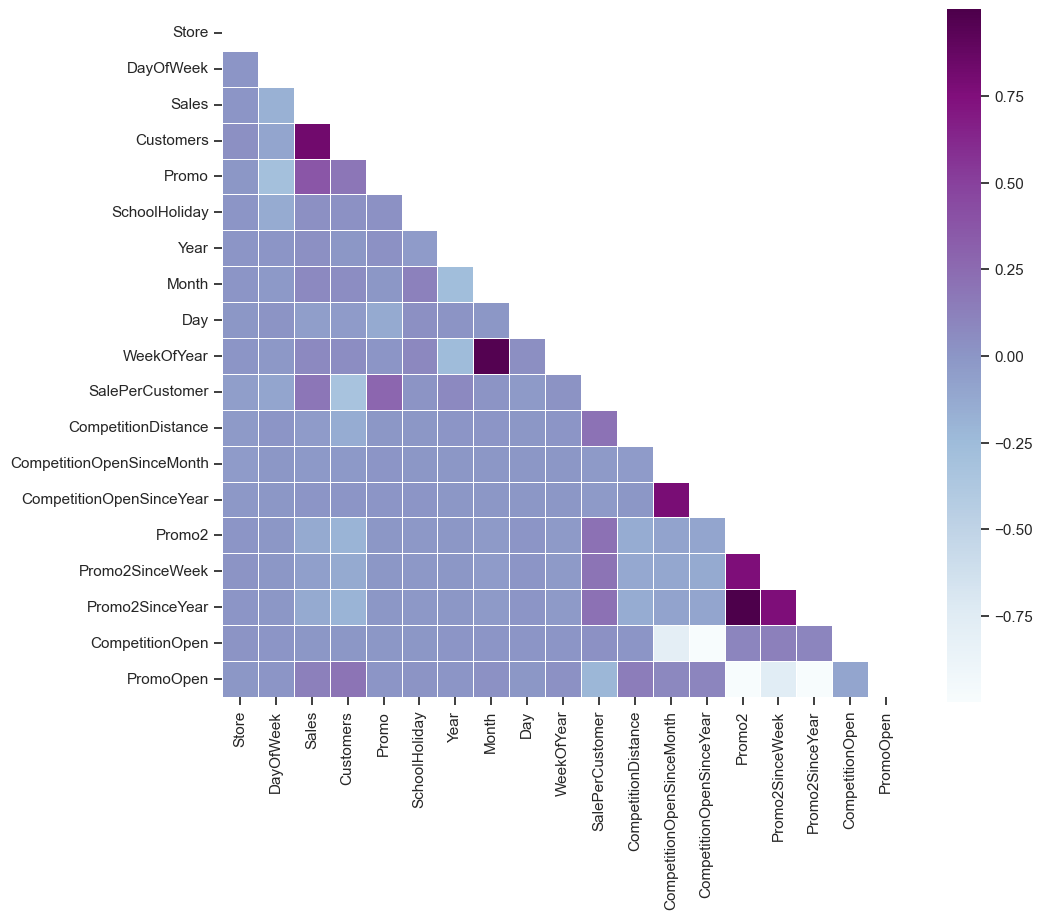

In [ ]:
### Correlational Analysis
# 전체적인 상관관계를 확인할 수 있음

# Compute the correlation matrix
# exclude 'Open' variable
corr_all = train_store.drop('Open', axis= 1).corr(numeric_only= True)    
# drop(): 행이나 열을 삭제하는 것, axis= 1: columns 행 (default= 0)
# corr(): 행에서 pairwise(쌍별) 상관관계를 계산함
# numeric_only= True: 숫자 행만 계산하기
# print(train_store.dtypes): 타입 확인하기

# 피어슨 상관계수 계산함

# Open 을 제외하는 이유: 이진변수로, 

# Generate a mask for the upper triangle    # 대칭 행렬의 상단 삼각형을 가리는 것
mask= np.zeros_like(corr_all, dtype= bool)  # zeros_like: 상관계수의 모든 값을 0으로 채우기 
                                            # dtype= bool: 배열의 자료형을 불리언으로 만들기 (default: False)
mask[np.triu_indices_from(mask)]= True      # triu_indices_from(): 배열의 상삼각형에 해당하는 인덱스를 가져옴
                                            # mask[np.triu_indices_from()]= True: 상삼각 해당 배열만 True로 변경

# Set up the matplotlib figure
f, ax = plt.subplots(figsize = (11, 9))   # f: 전체 그림 영역  # ax: 실제 그래프가 그려질 축

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr_all, mask= mask,           # mask= mask: mask를 마스킹함(가림)
            square= True, linewidths= 0.5, ax= ax,   # square= True: 정사각형  # linewidth: 셀 사이의 경계선
            cmap= "BuPu")
plt.show()

# Sales-Customers 과 매우 강한 상관관계를 보이는 것 같음
# Sales-Promo 도 긍정의 상관관계를 가짐
# DayOfWeek-Promo 가 음의 상관관계를 가지는 것 같음


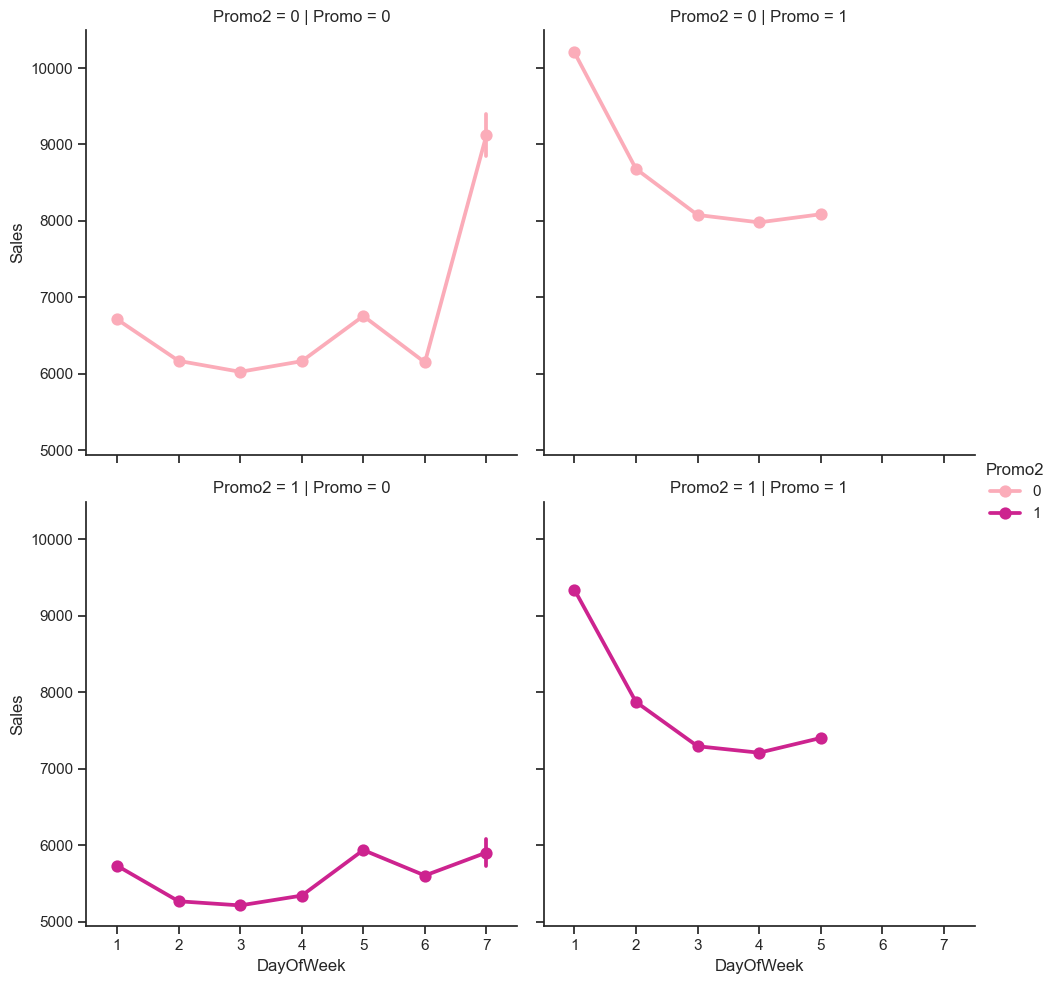

In [ ]:
# sale per customer trends

sns.catplot(data= train_store,
            x= 'DayOfWeek',
            y= 'Sales',
            col= 'Promo',
            row= 'Promo2',
            hue= 'Promo2',
            palette= 'RdPu',
            kind= 'point')

# Promo 가 없고 진행되지도 않고있는 상태: 일요일이 가장 판매액이 높음
# -> C는 일요일 휴무, 따라서 A, B, D 에서만 나오는 데이터임
# Promo 가 하나만 있거나 둘 다 있을 때: 월요일이 가장 판매액이 높음
# Promo2 는 판매액과 큰 상관관계가 없는 것으로 보임

In [ ]:
# 결론

# 가장 많이 팔리고 고객이 많은 가게 유형: A
# 고객 당 판매액이 가장 높은 가게 유형: D -> 구매 금액이 높다는 것을 의미함(Buyer Cart)~ 다양한 종류 판매를 고려해보기
# 고객 당 판매액이 갖아 낮은 가게 유형: B -> 작은 물품이나 적은 양의 소비를 함 -> 좋은 가능성을 가짐
# 고객들은 프로모션을 진행할때 주로 월요일에 구매를 많이함 <-> 프로모션이 진행되지 않을때는 일요일에 구매를 많이함
# 프로모션이 진행되는 중(Promo2)는 판매액과 특별한 영향을 주지 않는 것으로 보임